**Verificación de Homogeneidad Poblacional del Dataset** 
Para garantizar la estabilidad del entrenamiento de la ResNet3D, se realizó un análisis estadístico exhaustivo sobre la totalidad de los datos procesados ($n = 1040$). El preprocesamiento mediante normalización Z-score permitió unificar las intensidades de dos fuentes de datos distintas (ImageCAS y ASOCA), eliminando sesgos derivados de diferentes protocolos de adquisición y fabricantes de tomógrafos.El análisis poblacional arrojó los siguientes resultados clave:Distribución Normalizada: El dataset presenta una media global de $\mu \approx 0$ ($-9.98 \times 10^{-10}$) y una desviación estándar unitaria ($\sigma = 1.0$), lo que sitúa los datos en un rango óptimo para la convergencia de los algoritmos de optimización.Identificación de Estructuras: La distribución multimodal refleja la composición tisular; mientras que el pico central agrupa tejidos blandos y fondo, las densidades en los rangos superiores ($> +2\sigma$) corresponden a estructuras de interés como arterias coronarias contrastadas y calcificaciones.Eficiencia Computacional: La transformación de los volúmenes a formato binario (Memmap) permite una lectura de alta velocidad con un consumo mínimo de memoria RAM, facilitando el procesamiento de grandes volúmenes de datos 3D.

Analizando la población completa (1040 volúmenes)...


100%|██████████| 1040/1040 [04:19<00:00,  4.00it/s]



--- RESULTADOS GLOBALES ---
Media Promedio: -9.984797e-10
Std Promedio:   1.000000


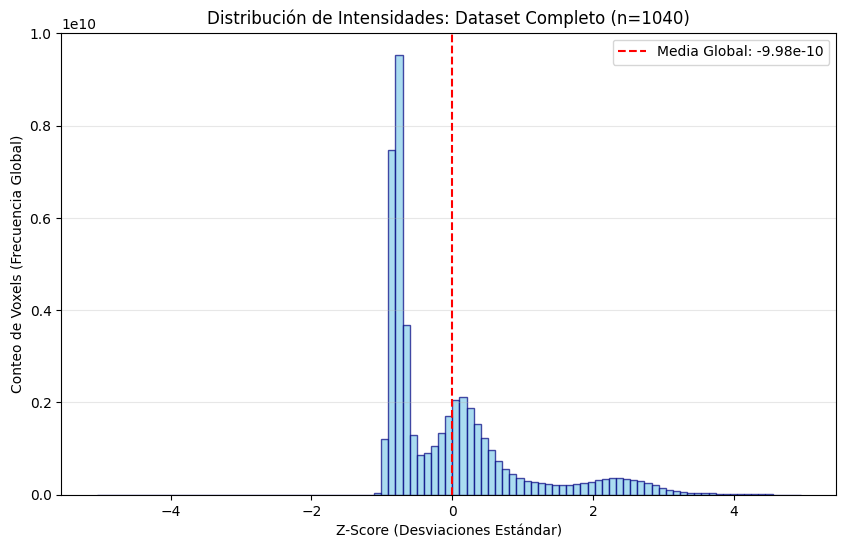


Gráfica guardada en: /media/mrsmile/IA/tesis/reportes/histograma_poblacional.png


In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


MEMMAP_DIR = "/media/mrsmile/IA/tesis/data/processed/memmap/volumes"
META_DIR = "/media/mrsmile/IA/tesis/data/processed/memmap/meta"
JSON_PATH = "/media/mrsmile/IA/tesis/data/metadata/data_split.json"
REPORTE_PATH = "/media/mrsmile/IA/tesis/reportes/histograma_poblacional.png"

os.makedirs(os.path.dirname(REPORTE_PATH), exist_ok=True)

with open(JSON_PATH, 'r') as f:
    split_data = json.load(f)


all_files = []
for ds in split_data.values():
    for group in ds.values():
        all_files.extend([f.replace('.nii.gz', '') for f in group])

print(f"Analizando la población completa ({len(all_files)} volúmenes)...")


global_means = []
global_stds = []

bins = np.linspace(-5, 5, 100)
total_histogram = np.zeros(len(bins)-1)

for name in tqdm(all_files):
    try:
        with open(os.path.join(META_DIR, f"{name}.json"), 'r') as f:
            meta = json.load(f)
        
        mmap_path = os.path.join(MEMMAP_DIR, f"{name}.dat")
        data = np.memmap(mmap_path, dtype='float32', mode='r', shape=tuple(meta['shape']))
        

        global_means.append(np.mean(data))
        global_stds.append(np.std(data))
        

        hist, _ = np.histogram(data, bins=bins)
        total_histogram += hist
    except Exception as e:
        print(f"Error en {name}: {e}")


print(f"\n--- RESULTADOS GLOBALES ---")
print(f"Media Promedio: {np.mean(global_means):.6e}")
print(f"Std Promedio:   {np.mean(global_stds):.6f}")

plt.figure(figsize=(10, 6))

plt.bar(bins[:-1], total_histogram, width=np.diff(bins), color='skyblue', edgecolor='navy', alpha=0.7)

plt.title(f"Distribución de Intensidades: Dataset Completo (n={len(all_files)})")
plt.xlabel("Z-Score (Desviaciones Estándar)")
plt.ylabel("Conteo de Voxels (Frecuencia Global)")
plt.axvline(0, color='red', linestyle='--', label=f"Media Global: {np.mean(global_means):.2e}")
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.savefig(REPORTE_PATH)
plt.show()

print(f"\nGráfica guardada en: {REPORTE_PATH}")

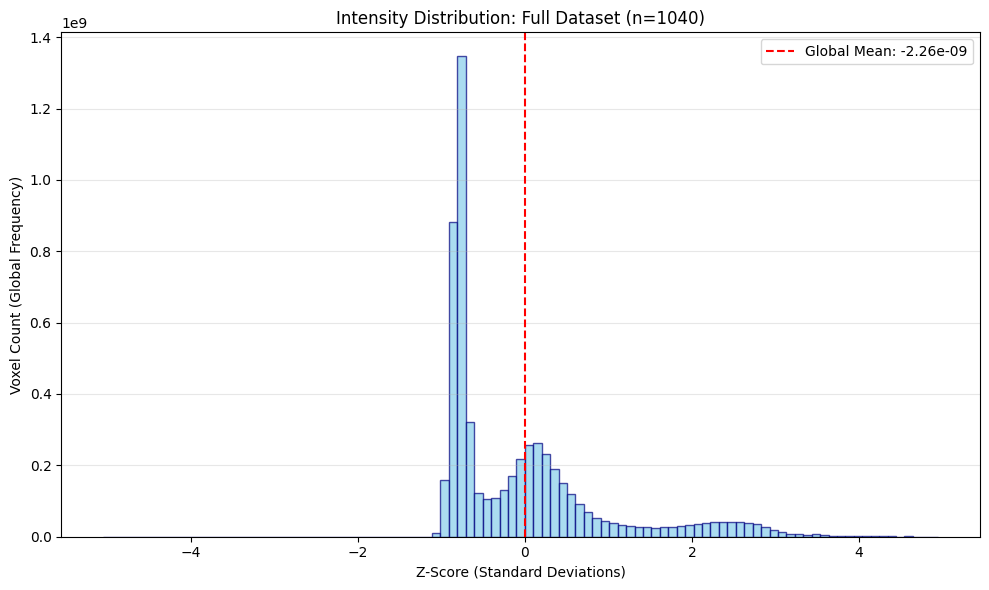


Figure saved to: /media/mrsmile/IA/tesis/reportes/intensity_distribution.png


In [2]:
plt.figure(figsize=(10, 6))
plt.bar(
    bins[:-1], total_histogram,
    width=np.diff(bins),
    color='skyblue', edgecolor='navy', alpha=0.7
)
plt.title(f"Intensity Distribution: Full Dataset (n={len(all_files)})")
plt.xlabel("Z-Score (Standard Deviations)")
plt.ylabel("Voxel Count (Global Frequency)")
plt.axvline(0, color='red', linestyle='--',
            label=f"Global Mean: {np.mean(global_means):.2e}")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(REPORT_PATH, dpi=150)
plt.show()

print(f"\nFigure saved to: {REPORT_PATH}")

**Análisis de Morfología Volumétrica y Resolución Espacial**
Para determinar la configuración óptima de la arquitectura ResNet3D y la estrategia de alimentación de datos, se realizó un análisis estadístico de las dimensiones estructurales y el espaciado de voxels (spacing) de los 1,040 volúmenes que componen el dataset unificado.A. Caracterización DimensionalEl análisis de las dimensiones (Figura [X]) reveló una mediana axial ($X, Y$) de 450 a 512 píxeles, mientras que la profundidad del volumen ($Z$) mostró una distribución más compacta, concentrada en los 230 cortes. Esta relación dimensional es fundamental para el diseño de la etapa de extracción de parches (patching):La consistencia en el eje $Z$ permite asegurar que un parche volumétrico de $128^3$ o $64^3$ voxels siempre contendrá información anatómica relevante sin riesgo de exceder los límites del volumen en la mayoría de los casos.B. Isotropía y Resolución del VoxelEl espaciado de voxels (resolución física en mm) es un factor crítico para evitar distorsiones morfológicas en las arterias coronarias. Los resultados indican:Espaciado Axial: Una resolución media de aproximadamente 0.4 mm, lo que garantiza una alta fidelidad en la captura de estructuras pequeñas.Espaciado Longitudinal ($Z$): Una concentración significativa en los 0.6 mm, mostrando una baja variabilidad (poca dispersión en el gráfico de puntos).Esta homogeneidad en la resolución espacial justifica la omisión de un proceso de re-muestreo (resampling) masivo, lo que reduce la carga computacional y preserva la integridad original de las imágenes durante el entrenamiento.

Analizando metadata de 1040 volúmenes...


100%|██████████| 1040/1040 [00:00<00:00, 12970.33it/s]


--- RESUMEN DE DIMENSIONES (Voxels) ---
           depth      height       width
mean  214.877885  454.504808  454.504808
min   138.000000  370.000000  370.000000
max   233.000000  633.000000  633.000000

--- RESUMEN DE RESOLUCIÓN (Spacing en mm) ---
      spacing_x  spacing_y  spacing_z
mean        0.4        0.4        0.6
min         0.4        0.4        0.6
max         0.4        0.4        0.6



/tmp/ipykernel_8315/3618326495.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['depth'], df['height'], df['width']], labels=['Z (Depth)', 'Y (Height)', 'X (Width)'])


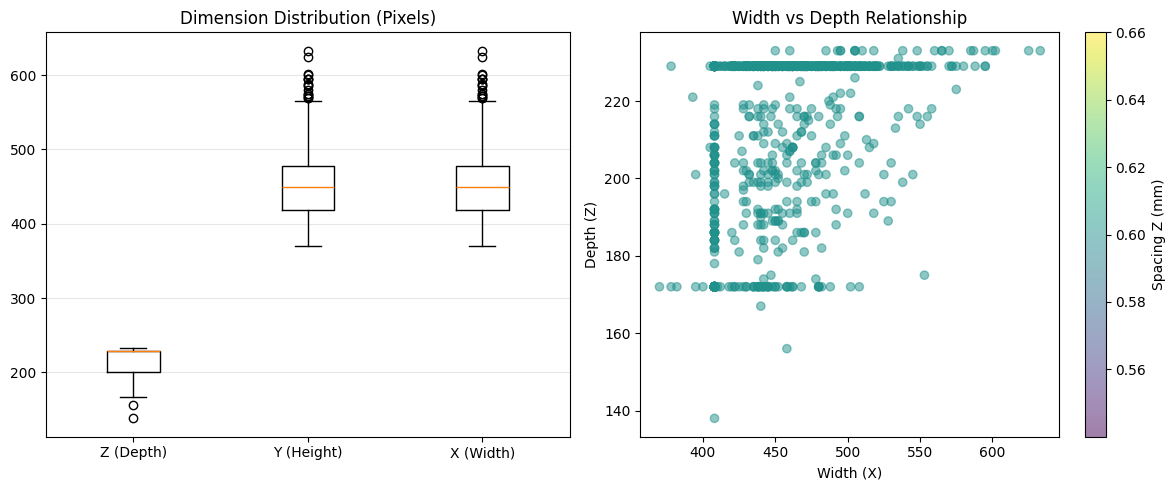

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURACIÓN ---
META_DIR = "/media/mrsmile/IA/tesis/data/processed/memmap/meta"
REPORT_DIR = "/media/mrsmile/IA/tesis/reportes"
os.makedirs(REPORT_DIR, exist_ok=True)

meta_files = [f for f in os.listdir(META_DIR) if f.endswith('.json')]

stats = []

print(f"Analizando metadata de {len(meta_files)} volúmenes...")

for f in tqdm(meta_files):
    with open(os.path.join(META_DIR, f), 'r') as file:
        meta = json.load(file)
        
        # Extraer datos (Z, Y, X)
        shape = meta['shape']
        spacing = meta['spacing'] # Generalmente (x, y, z) en SimpleITK
        
        stats.append({
            'name': f,
            'depth': shape[0],
            'height': shape[1],
            'width': shape[2],
            'spacing_x': spacing[0],
            'spacing_y': spacing[1],
            'spacing_z': spacing[2],
            'total_voxels': np.prod(shape)
        })

df = pd.DataFrame(stats)

# --- GENERAR INFORME ---
print("\n--- RESUMEN DE DIMENSIONES (Voxels) ---")
print(df[['depth', 'height', 'width']].describe().loc[['mean', 'min', 'max']])

print("\n--- RESUMEN DE RESOLUCIÓN (Spacing en mm) ---")
print(df[['spacing_x', 'spacing_y', 'spacing_z']].describe().loc[['mean', 'min', 'max']])

# --- GRÁFICA DE DISTRIBUCIÓN ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot([df['depth'], df['height'], df['width']], labels=['Z (Depth)', 'Y (Height)', 'X (Width)'])
plt.title("Dimension Distribution (Pixels)")
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
scatter = plt.scatter(df['width'], df['depth'], alpha=0.5, c=df['spacing_z'], cmap='viridis')
plt.colorbar(scatter, label='Spacing Z (mm)')
plt.xlabel("Width (X)")
plt.ylabel("Depth (Z)")
plt.title("Width vs Depth Relationship")

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "dimension_analysis.png"), dpi=150)
plt.show()

Reading spacing asoca: 100%|██████████| 10/10 [00:00<00:00, 70256.35it/s]
/tmp/ipykernel_8315/70594767.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_icas, data_asoca], labels=['ImageCAS', 'ASOCA'])
/tmp/ipykernel_8315/70594767.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_icas, data_asoca], labels=['ImageCAS', 'ASOCA'])
/tmp/ipykernel_8315/70594767.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_icas, data_asoca], labels=['ImageCAS', 'ASOCA'])


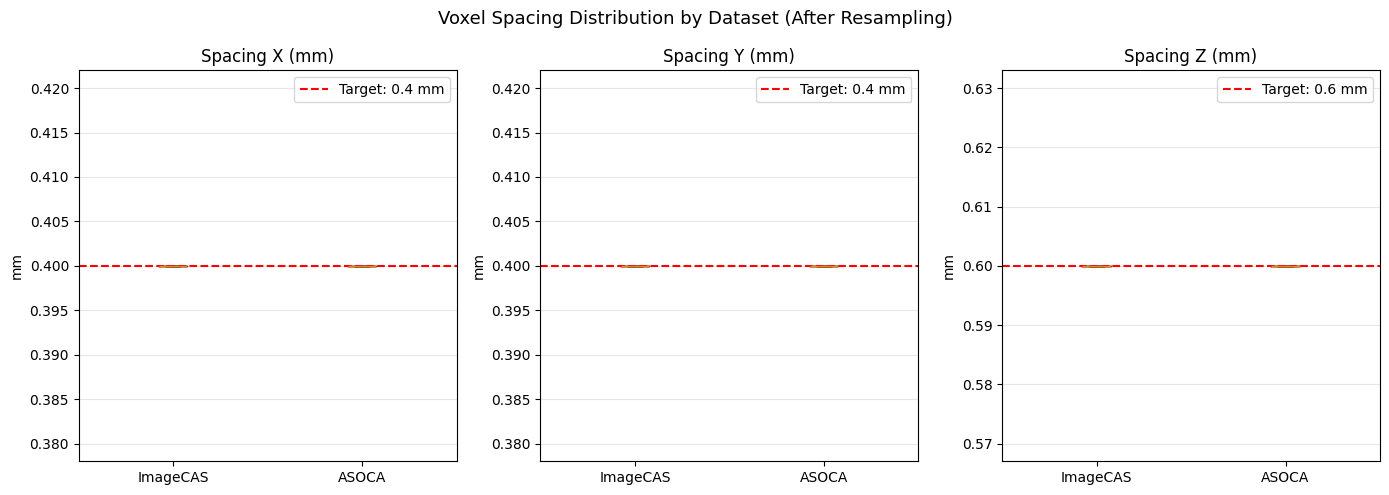

Saved: spacing_by_dataset.png


Sampling volumes: 100%|██████████| 5/5 [00:00<00:00,  5.65it/s]


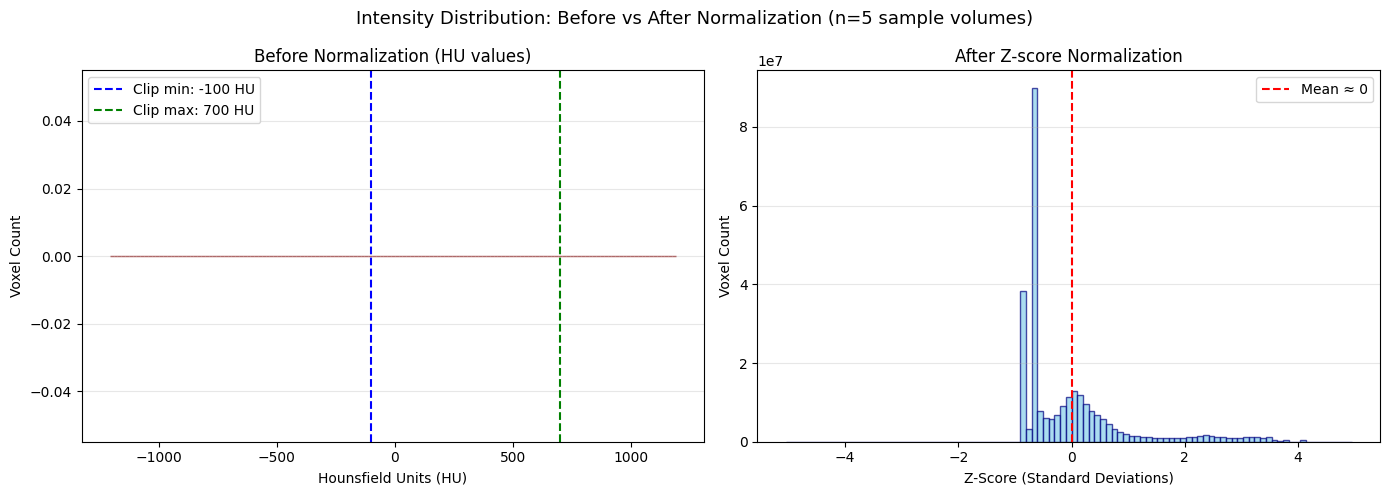

Saved: normalization_comparison.png


In [5]:
import os
import json
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

REPORT_DIR  = "/media/mrsmile/IA/tesis/reportes"
META_DIR    = "/media/mrsmile/IA/tesis/data/processed/memmap/meta"
RAW_DIR     = "/media/mrsmile/IA/tesis/data/processed/resampled"
JSON_PATH   = "/media/mrsmile/IA/tesis/data/metadata/data_split.json"
MEMMAP_DIR  = "/media/mrsmile/IA/tesis/data/processed/memmap/volumes"

os.makedirs(REPORT_DIR, exist_ok=True)

with open(JSON_PATH, 'r') as f:
    split_data = json.load(f)

# ============================================================
# GRÁFICA 1: Spacing por dataset (ASOCA vs ImageCAS)
# ============================================================
spacings = {'imagecas': [], 'asoca': []}

for ds_name, groups in split_data.items():
    for group in groups.values():
        for fname in tqdm(group, desc=f"Reading spacing {ds_name}"):
            base = fname.replace('.nii.gz', '')
            meta_path = os.path.join(META_DIR, f"{base}.json")
            if not os.path.exists(meta_path):
                continue
            with open(meta_path, 'r') as f:
                meta = json.load(f)
            spacings[ds_name].append(meta['spacing'])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes_labels = ['Spacing X (mm)', 'Spacing Y (mm)', 'Spacing Z (mm)']

for i, ax in enumerate(axes):
    data_icas  = [s[i] for s in spacings['imagecas']]
    data_asoca = [s[i] for s in spacings['asoca']]
    ax.boxplot([data_icas, data_asoca], labels=['ImageCAS', 'ASOCA'])
    ax.axhline([0.4, 0.4, 0.6][i], color='red', linestyle='--',
               label=f"Target: {[0.4, 0.4, 0.6][i]} mm")
    ax.set_title(axes_labels[i])
    ax.set_ylabel("mm")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Voxel Spacing Distribution by Dataset (After Resampling)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "spacing_by_dataset.png"), dpi=150)
plt.show()
print("Saved: spacing_by_dataset.png")


# ============================================================
# GRÁFICA 2: Intensidades antes vs después de normalización
# ============================================================
# Toma 5 volúmenes aleatorios para la comparativa
sample_files = []
for groups in split_data['imagecas'].values():
    sample_files.extend(groups[:2])
sample_files = sample_files[:5]

bins = np.linspace(-1200, 1200, 150)
bins_norm = np.linspace(-5, 5, 100)

hist_raw  = np.zeros(len(bins) - 1)
hist_norm = np.zeros(len(bins_norm) - 1)

for fname in tqdm(sample_files, desc="Sampling volumes"):
    base = fname.replace('.nii.gz', '')

    # Antes: leer desde resampled (raw HU)
    raw_path = os.path.join(RAW_DIR, f"{base}.nii.gz")
    if os.path.exists(raw_path):
        img = sitk.ReadImage(raw_path)
        arr = sitk.GetArrayFromImage(img).astype(np.float32)
        h, _ = np.histogram(arr, bins=bins)
        hist_raw += h

    # Después: leer desde memmap (normalizado)
    with open(os.path.join(META_DIR, f"{base}.json"), 'r') as f:
        meta = json.load(f)
    data = np.memmap(
        os.path.join(MEMMAP_DIR, f"{base}.dat"),
        dtype='float32', mode='r', shape=tuple(meta['shape'])
    )
    h2, _ = np.histogram(data, bins=bins_norm)
    hist_norm += h2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bins[:-1], hist_raw, width=np.diff(bins),
            color='salmon', edgecolor='darkred', alpha=0.7)
axes[0].axvline(-100, color='blue', linestyle='--', label='Clip min: -100 HU')
axes[0].axvline(700,  color='green', linestyle='--', label='Clip max: 700 HU')
axes[0].set_title("Before Normalization (HU values)")
axes[0].set_xlabel("Hounsfield Units (HU)")
axes[0].set_ylabel("Voxel Count")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(bins_norm[:-1], hist_norm, width=np.diff(bins_norm),
            color='skyblue', edgecolor='navy', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='Mean ≈ 0')
axes[1].set_title("After Z-score Normalization")
axes[1].set_xlabel("Z-Score (Standard Deviations)")
axes[1].set_ylabel("Voxel Count")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Intensity Distribution: Before vs After Normalization (n=5 sample volumes)",
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "normalization_comparison.png"), dpi=150)
plt.show()
print("Saved: normalization_comparison.png")